# Model - Gaussian

This example shows how to use `lmfit_global.simplefit` code to fit data with simple gaussian. 

This example is similar to `model_gaussian.py` of [lmfit examples](https://lmfit.github.io/lmfit-py/examples/index.html) or [github link](https://github.com/lmfit/lmfit-py/tree/master/examples)


In [1]:
try:
    from lmfit_global import simplefit
except (ImportError, ModuleNotFoundError):
    import os, sys
    ROOT = os.path.abspath("..") # parent folder of examples
    sys.path.insert(0, ROOT)
    from lmfit_global import simplefit

import matplotlib.pyplot as plt
# sys.path

In [2]:
import os
import numpy as np
dpath = './data'  # data path

# --- Load data (skip header) ---
file = 'model1d_gauss.dat' # data
file = os.path.join(
    dpath,
    file
)

data = np.loadtxt(file)
x = data[:, 0]  # first  columm as x
y = data[:, 1]  # second column as y


Fit status smplefit:
Best-fit parameters:         [8.88021893 5.65866102 0.69765478]
Asymptotic error:            [0.11359522 0.01030495 0.01030505]

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 33
    # data points      = 101
    # variables        = 3
    chi-square         = 3.40883599
    reduced chi-square = 0.03478404
    Akaike info crit   = -336.263713
    Bayesian info crit = -328.418352
    R-squared          = 0.98533348
[[Variables]]
    amplitude:  8.88021893 +/- 0.11359522 (1.28%) (init = 5)
    center:     5.65866102 +/- 0.01030495 (0.18%) (init = 5)
    sigma:      0.69765478 +/- 0.01030505 (1.48%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, sigma) = +0.5774


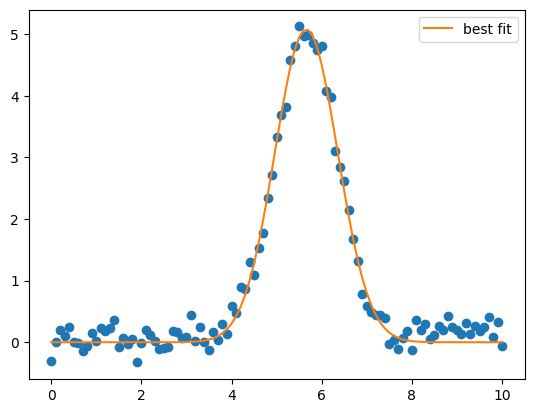

In [3]:
from lmfit_global.utils import lineshapes

p0 = [5.0, 5.0, 1.0]   # init params
### --- or in form of --- ###
# p0 = {
#     'amplitude': {'value':5.0, 'vary': True},
#     'center':    {'value':5.0, 'vary': True},
#     'sigma':     {'value':1.0, 'vary': True},
# }                     # init params

result = None
return_result = True
if return_result:
    popt, perr, result = simplefit(
        lineshapes.gaussian,
        p0=p0,
        x=x,
        y=y,
        err=1.0,
        fit_method="leastsq",
        return_result=return_result
    )
else:
    popt, perr = simplefit(
        lineshapes.gaussian,
        p0=p0,
        x=x,
        y=y,
        err=1.0,
        fit_method="leastsq",
        return_result=False
    )

print("\nFit status smplefit:")
print("====================")
print("Best-fit parameters:        ", popt)
print("Asymptotic error:           ", perr)
print()

if result:
    import lmfit
    print(lmfit.fit_report(result))

yfit  = lineshapes.gaussian(x, *popt)
plt.plot(x, y, 'o')
plt.plot(x, yfit, '-', label='best fit')
plt.legend()
plt.show()